# 실전 데이터 분석 2
- 범죄 현황 분석
- 서울시 5대 범죄 발생 현황 통계

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'New Gulim'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

In [57]:
CRIME = pd.read_excel('CRIME.xlsx')

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [58]:
CRIME.head(3)

,자치구별(1),자치구별(2),2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8,2024.9,2024.10,2024.11
0,자치구별(1),자치구별(2),합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계
1,자치구별(1),자치구별(2),소계,소계,살인,살인,강도,강도,강간·강제추행,강간·강제추행,절도,절도,폭력,폭력
2,자치구별(1),자치구별(2),발생,검거,발생,검거,발생,검거,발생,검거,발생,검거,발생,검거


In [59]:
CRIME = pd.read_excel('CRIME.xlsx', skiprows=3)

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [60]:
CRIME.head(3)

,자치구별(1),자치구별(2),발생,검거,발생.1,검거.1,발생.2,검거.2,발생.3,검거.3,발생.4,검거.4,발생.5,검거.5
0,합계,소계,80819,63275,149,137,87,85,5523,5183,35506,22796,39554,35074
1,NaN,종로구,2765,3248,2,3,5,10,209,933,1183,1056,1366,1246
2,NaN,중구,2955,2180,5,4,5,5,177,121,1398,816,1370,1234


In [61]:
del CRIME['자치구별(1)']
del CRIME['발생']
del CRIME['검거']

In [62]:
CRIME.head(2)

,자치구별(2),발생.1,검거.1,발생.2,검거.2,발생.3,검거.3,발생.4,검거.4,발생.5,검거.5
0,소계,149,137,87,85,5523,5183,35506,22796,39554,35074
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246


In [63]:
CRIME.columns = ['구별', '살인발생', '살인검거', '강도발생', '강도검거', '강간강제추행발생', '강간강제추행검거', '절도발생', '절도검거', '폭력발생', '폭력검거']

In [64]:
CRIME.head(3)

,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거
0,소계,149,137,87,85,5523,5183,35506,22796,39554,35074
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246
2,중구,5,4,5,5,177,121,1398,816,1370,1234


In [65]:
CRIME.drop(0, inplace=True)

In [66]:
CRIME.head(2)

,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246
2,중구,5,4,5,5,177,121,1398,816,1370,1234


## 검거율 추가

In [67]:
CRIME

,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246
2,중구,5,4,5,5,177,121,1398,816,1370,1234
3,용산구,10,6,4,3,267,235,1082,589,1959,1642
4,성동구,5,6,3,3,114,90,966,544,1029,867
5,광진구,2,2,6,7,235,183,1320,942,1307,1085
6,동대문구,7,6,4,2,125,110,1617,1060,1463,1304
7,중랑구,5,5,2,2,143,116,1437,931,1582,1409
8,성북구,3,2,1,1,146,109,884,578,1150,1059
9,강북구,6,6,-,-,142,112,970,835,1171,1108
10,도봉구,7,3,-,1,73,61,800,520,861,794


In [68]:
CRIME.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   구별        25 non-null     object
 1   살인발생      25 non-null     int64 
 2   살인검거      25 non-null     int64 
 3   강도발생      25 non-null     object
 4   강도검거      25 non-null     object
 5   강간강제추행발생  25 non-null     int64 
 6   강간강제추행검거  25 non-null     int64 
 7   절도발생      25 non-null     int64 
 8   절도검거      25 non-null     int64 
 9   폭력발생      25 non-null     int64 
 10  폭력검거      25 non-null     int64 
dtypes: int64(8), object(3)
memory usage: 2.3+ KB


In [69]:
CRIME.loc[9, '강도발생']

'-'

In [70]:
type(CRIME.loc[9, '강도발생'])

str

In [71]:
CRIME.replace('-', 0) # 원본 수정 안함.

C:\Users\IT\AppData\Local\Temp\ipykernel_17520\4046002645.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CRIME.replace('-', 0) # 원본 수정 안함.


,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246
2,중구,5,4,5,5,177,121,1398,816,1370,1234
3,용산구,10,6,4,3,267,235,1082,589,1959,1642
4,성동구,5,6,3,3,114,90,966,544,1029,867
5,광진구,2,2,6,7,235,183,1320,942,1307,1085
6,동대문구,7,6,4,2,125,110,1617,1060,1463,1304
7,중랑구,5,5,2,2,143,116,1437,931,1582,1409
8,성북구,3,2,1,1,146,109,884,578,1150,1059
9,강북구,6,6,0,0,142,112,970,835,1171,1108
10,도봉구,7,3,0,1,73,61,800,520,861,794


In [72]:
CRIME = CRIME.replace('-', 0)

C:\Users\IT\AppData\Local\Temp\ipykernel_17520\3485709669.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CRIME = CRIME.replace('-', 0)


In [73]:
CRIME.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   구별        25 non-null     object
 1   살인발생      25 non-null     int64 
 2   살인검거      25 non-null     int64 
 3   강도발생      25 non-null     int64 
 4   강도검거      25 non-null     int64 
 5   강간강제추행발생  25 non-null     int64 
 6   강간강제추행검거  25 non-null     int64 
 7   절도발생      25 non-null     int64 
 8   절도검거      25 non-null     int64 
 9   폭력발생      25 non-null     int64 
 10  폭력검거      25 non-null     int64 
dtypes: int64(10), object(1)
memory usage: 2.3+ KB


### 검거율 = (검거/발생) * 100

In [74]:
crime_index = ['살인', '강도', '강간강제추행', '절도', '폭력']

In [75]:
for crime in crime_index:
    CRIME[crime+'검거율'] = (CRIME[crime+'검거'] / CRIME[crime+'발생']) * 100

In [76]:
CRIME

,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246,150.000000,200.000000,446.411483,89.264582,91.215227
2,중구,5,4,5,5,177,121,1398,816,1370,1234,80.000000,100.000000,68.361582,58.369099,90.072993
3,용산구,10,6,4,3,267,235,1082,589,1959,1642,60.000000,75.000000,88.014981,54.436229,83.818275
4,성동구,5,6,3,3,114,90,966,544,1029,867,120.000000,100.000000,78.947368,56.314700,84.256560
5,광진구,2,2,6,7,235,183,1320,942,1307,1085,100.000000,116.666667,77.872340,71.363636,83.014537
6,동대문구,7,6,4,2,125,110,1617,1060,1463,1304,85.714286,50.000000,88.000000,65.553494,89.131921
7,중랑구,5,5,2,2,143,116,1437,931,1582,1409,100.000000,100.000000,81.118881,64.787752,89.064475
8,성북구,3,2,1,1,146,109,884,578,1150,1059,66.666667,100.000000,74.657534,65.384615,92.086957
9,강북구,6,6,0,0,142,112,970,835,1171,1108,100.000000,NaN,78.873239,86.082474,94.619983
10,도봉구,7,3,0,1,73,61,800,520,861,794,42.857143,inf,83.561644,65.000000,92.218351


In [77]:
CRIME['살인검거율'] > 100

1      True
2     False
3     False
4      True
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21     True
22    False
23     True
24    False
25     True
Name: 살인검거율, dtype: bool

In [78]:
CRIME.loc[CRIME['살인검거율'] > 100]

,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246,150.000000,200.000000,446.411483,89.264582,91.215227
4,성동구,5,6,3,3,114,90,966,544,1029,867,120.000000,100.000000,78.947368,56.314700,84.256560
21,관악구,4,5,3,2,338,284,1971,1212,2169,2013,125.000000,66.666667,84.023669,61.491629,92.807746
23,강남구,16,17,17,12,640,533,2097,1140,3337,2868,106.250000,70.588235,83.281250,54.363376,85.945460
25,강동구,3,4,4,4,164,140,1662,990,1517,1372,133.333333,100.000000,85.365854,59.566787,90.441661


In [79]:
CRIME.loc[CRIME['살인검거율'] > 100, '살인검거율']

1     150.000000
4     120.000000
21    125.000000
23    106.250000
25    133.333333
Name: 살인검거율, dtype: float64

In [80]:
CRIME.loc[CRIME['살인검거율'] > 100, '살인검거율'] = 100

In [81]:
CRIME

,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246,100.000000,200.000000,446.411483,89.264582,91.215227
2,중구,5,4,5,5,177,121,1398,816,1370,1234,80.000000,100.000000,68.361582,58.369099,90.072993
3,용산구,10,6,4,3,267,235,1082,589,1959,1642,60.000000,75.000000,88.014981,54.436229,83.818275
4,성동구,5,6,3,3,114,90,966,544,1029,867,100.000000,100.000000,78.947368,56.314700,84.256560
5,광진구,2,2,6,7,235,183,1320,942,1307,1085,100.000000,116.666667,77.872340,71.363636,83.014537
6,동대문구,7,6,4,2,125,110,1617,1060,1463,1304,85.714286,50.000000,88.000000,65.553494,89.131921
7,중랑구,5,5,2,2,143,116,1437,931,1582,1409,100.000000,100.000000,81.118881,64.787752,89.064475
8,성북구,3,2,1,1,146,109,884,578,1150,1059,66.666667,100.000000,74.657534,65.384615,92.086957
9,강북구,6,6,0,0,142,112,970,835,1171,1108,100.000000,NaN,78.873239,86.082474,94.619983
10,도봉구,7,3,0,1,73,61,800,520,861,794,42.857143,inf,83.561644,65.000000,92.218351


In [82]:
for crime in crime_index:
    CRIME.loc[CRIME[crime+'검거율'] > 100, crime+'검거율'] = 100

In [83]:
CRIME

,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246,100.000000,100.000000,100.000000,89.264582,91.215227
2,중구,5,4,5,5,177,121,1398,816,1370,1234,80.000000,100.000000,68.361582,58.369099,90.072993
3,용산구,10,6,4,3,267,235,1082,589,1959,1642,60.000000,75.000000,88.014981,54.436229,83.818275
4,성동구,5,6,3,3,114,90,966,544,1029,867,100.000000,100.000000,78.947368,56.314700,84.256560
5,광진구,2,2,6,7,235,183,1320,942,1307,1085,100.000000,100.000000,77.872340,71.363636,83.014537
6,동대문구,7,6,4,2,125,110,1617,1060,1463,1304,85.714286,50.000000,88.000000,65.553494,89.131921
7,중랑구,5,5,2,2,143,116,1437,931,1582,1409,100.000000,100.000000,81.118881,64.787752,89.064475
8,성북구,3,2,1,1,146,109,884,578,1150,1059,66.666667,100.000000,74.657534,65.384615,92.086957
9,강북구,6,6,0,0,142,112,970,835,1171,1108,100.000000,NaN,78.873239,86.082474,94.619983
10,도봉구,7,3,0,1,73,61,800,520,861,794,42.857143,100.000000,83.561644,65.000000,92.218351


In [84]:
CRIME.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   구별         25 non-null     object 
 1   살인발생       25 non-null     int64  
 2   살인검거       25 non-null     int64  
 3   강도발생       25 non-null     int64  
 4   강도검거       25 non-null     int64  
 5   강간강제추행발생   25 non-null     int64  
 6   강간강제추행검거   25 non-null     int64  
 7   절도발생       25 non-null     int64  
 8   절도검거       25 non-null     int64  
 9   폭력발생       25 non-null     int64  
 10  폭력검거       25 non-null     int64  
 11  살인검거율      25 non-null     float64
 12  강도검거율      23 non-null     float64
 13  강간강제추행검거율  25 non-null     float64
 14  절도검거율      25 non-null     float64
 15  폭력검거율      25 non-null     float64
dtypes: float64(5), int64(10), object(1)
memory usage: 3.3+ KB


In [85]:
CRIME.fillna(100, inplace=True)

In [86]:
CRIME.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   구별         25 non-null     object 
 1   살인발생       25 non-null     int64  
 2   살인검거       25 non-null     int64  
 3   강도발생       25 non-null     int64  
 4   강도검거       25 non-null     int64  
 5   강간강제추행발생   25 non-null     int64  
 6   강간강제추행검거   25 non-null     int64  
 7   절도발생       25 non-null     int64  
 8   절도검거       25 non-null     int64  
 9   폭력발생       25 non-null     int64  
 10  폭력검거       25 non-null     int64  
 11  살인검거율      25 non-null     float64
 12  강도검거율      25 non-null     float64
 13  강간강제추행검거율  25 non-null     float64
 14  절도검거율      25 non-null     float64
 15  폭력검거율      25 non-null     float64
dtypes: float64(5), int64(10), object(1)
memory usage: 3.3+ KB


In [87]:
CRIME.head(3)

,구별,살인발생,살인검거,강도발생,강도검거,강간강제추행발생,강간강제추행검거,절도발생,절도검거,폭력발생,폭력검거,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
1,종로구,2,3,5,10,209,933,1183,1056,1366,1246,100.0,100.0,100.000000,89.264582,91.215227
2,중구,5,4,5,5,177,121,1398,816,1370,1234,80.0,100.0,68.361582,58.369099,90.072993
3,용산구,10,6,4,3,267,235,1082,589,1959,1642,60.0,75.0,88.014981,54.436229,83.818275


In [88]:
for crime in crime_index:
    del CRIME[crime+'검거']

In [89]:
CRIME.head(3)

,구별,살인발생,강도발생,강간강제추행발생,절도발생,폭력발생,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
1,종로구,2,5,209,1183,1366,100.0,100.0,100.000000,89.264582,91.215227
2,중구,5,5,177,1398,1370,80.0,100.0,68.361582,58.369099,90.072993
3,용산구,10,4,267,1082,1959,60.0,75.0,88.014981,54.436229,83.818275


In [90]:
for crime in CRIME.columns:
    if crime.endswith('발생'):
        print(crime[:-2])

살인
강도
강간강제추행
절도
폭력


In [92]:
for crime in CRIME.columns:
    if crime.endswith('발생'):
        CRIME.rename(columns = {crime:crime[:-2]}, inplace=True)
    else:
        pass

In [93]:
CRIME

,구별,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
1,종로구,2,5,209,1183,1366,100.000000,100.000000,100.000000,89.264582,91.215227
2,중구,5,5,177,1398,1370,80.000000,100.000000,68.361582,58.369099,90.072993
3,용산구,10,4,267,1082,1959,60.000000,75.000000,88.014981,54.436229,83.818275
4,성동구,5,3,114,966,1029,100.000000,100.000000,78.947368,56.314700,84.256560
5,광진구,2,6,235,1320,1307,100.000000,100.000000,77.872340,71.363636,83.014537
6,동대문구,7,4,125,1617,1463,85.714286,50.000000,88.000000,65.553494,89.131921
7,중랑구,5,2,143,1437,1582,100.000000,100.000000,81.118881,64.787752,89.064475
8,성북구,3,1,146,884,1150,66.666667,100.000000,74.657534,65.384615,92.086957
9,강북구,6,0,142,970,1171,100.000000,100.000000,78.873239,86.082474,94.619983
10,도봉구,7,0,73,800,861,42.857143,100.000000,83.561644,65.000000,92.218351


# 데이터 정규화 (Normalize)
- MinMaxScaler : 이상치(Outlier)에 의해 결과가 외곡될 수 있음.

In [94]:
from sklearn import preprocessing

In [95]:
x = CRIME[crime_index]

In [97]:
x

,살인,강도,강간강제추행,절도,폭력
1,2,5,209,1183,1366
2,5,5,177,1398,1370
3,10,4,267,1082,1959
4,5,3,114,966,1029
5,2,6,235,1320,1307
6,7,4,125,1617,1463
7,5,2,143,1437,1582
8,3,1,146,884,1150
9,6,0,142,970,1171
10,7,0,73,800,861


In [98]:
min_max_scaler = preprocessing.MinMaxScaler()

In [99]:
x_scaled = min_max_scaler.fit_transform(x.astype(float))

In [100]:
x_scaled

array([[0.06666667, 0.29411765, 0.23985891, 0.22502938, 0.203958  ],
       [0.26666667, 0.29411765, 0.18342152, 0.35135135, 0.20557351],
       [0.6       , 0.23529412, 0.34215168, 0.16568743, 0.44345719],
       [0.26666667, 0.17647059, 0.07231041, 0.09753231, 0.06785137],
       [0.06666667, 0.35294118, 0.28571429, 0.30552291, 0.18012924],
       [0.4       , 0.23529412, 0.09171076, 0.4800235 , 0.24313409],
       [0.26666667, 0.11764706, 0.12345679, 0.37426557, 0.29119548],
       [0.13333333, 0.05882353, 0.1287478 , 0.0493537 , 0.11672052],
       [0.33333333, 0.        , 0.12169312, 0.09988249, 0.12520194],
       [0.4       , 0.        , 0.        , 0.        , 0.        ],
       [0.4       , 0.17647059, 0.1287478 , 0.4159812 , 0.23263328],
       [0.53333333, 0.05882353, 0.10405644, 0.4212691 , 0.28150242],
       [0.13333333, 0.        , 0.10229277, 0.12573443, 0.01817447],
       [0.2       , 0.23529412, 0.75837743, 0.39424207, 0.42326333],
       [0.2       , 0.05882353, 0.

In [101]:
CRIME_norm = pd.DataFrame(x_scaled)

In [102]:
CRIME_norm

,0,1,2,3,4
0,0.066667,0.294118,0.239859,0.225029,0.203958
1,0.266667,0.294118,0.183422,0.351351,0.205574
2,0.600000,0.235294,0.342152,0.165687,0.443457
3,0.266667,0.176471,0.072310,0.097532,0.067851
4,0.066667,0.352941,0.285714,0.305523,0.180129
5,0.400000,0.235294,0.091711,0.480024,0.243134
6,0.266667,0.117647,0.123457,0.374266,0.291195
7,0.133333,0.058824,0.128748,0.049354,0.116721
8,0.333333,0.000000,0.121693,0.099882,0.125202
9,0.400000,0.000000,0.000000,0.000000,0.000000


In [103]:
CRIME_norm = pd.DataFrame(x_scaled, columns=x.columns, index=CRIME['구별'])

In [106]:
CRIME_norm.head(3)

,살인,강도,강간강제추행,절도,폭력
구별,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958
중구,0.266667,0.294118,0.183422,0.351351,0.205574
용산구,0.600000,0.235294,0.342152,0.165687,0.443457


In [107]:
CRIME.head(1)

,구별,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
1,종로구,2,5,209,1183,1366,100.0,100.0,100.0,89.264582,91.215227


In [108]:
CRIME_norm.head(1)

,살인,강도,강간강제추행,절도,폭력
구별,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958


In [109]:
for crime in crime_index:
    CRIME_norm[crime+'검거율'] = CRIME[crime+'검거율']

In [111]:
CRIME_norm.head(2)

,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
구별,,,,,,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958,NaN,NaN,NaN,NaN,NaN
중구,0.266667,0.294118,0.183422,0.351351,0.205574,NaN,NaN,NaN,NaN,NaN


In [116]:
CRIME.set_index('구별', inplace=True)

In [117]:
for crime in crime_index:
    CRIME_norm[crime+'검거율'] = CRIME[crime+'검거율']

In [119]:
CRIME_norm.head(2)

,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율
구별,,,,,,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958,100.0,100.0,100.000000,89.264582,91.215227
중구,0.266667,0.294118,0.183422,0.351351,0.205574,80.0,100.0,68.361582,58.369099,90.072993


In [120]:
CRIME_norm.loc[:, '살인':'폭력']

,살인,강도,강간강제추행,절도,폭력
구별,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958
중구,0.266667,0.294118,0.183422,0.351351,0.205574
용산구,0.600000,0.235294,0.342152,0.165687,0.443457
성동구,0.266667,0.176471,0.072310,0.097532,0.067851
광진구,0.066667,0.352941,0.285714,0.305523,0.180129
동대문구,0.400000,0.235294,0.091711,0.480024,0.243134
중랑구,0.266667,0.117647,0.123457,0.374266,0.291195
성북구,0.133333,0.058824,0.128748,0.049354,0.116721
강북구,0.333333,0.000000,0.121693,0.099882,0.125202


In [121]:
CRIME_norm.loc[:, '살인':'폭력'].sum()

살인        8.266667
강도        5.117647
강간강제추행    6.522046
절도        9.110458
폭력        7.281502
dtype: float64

In [123]:
CRIME_norm.loc[:, '살인':'폭력'].sum(axis=1)

구별
종로구     1.029631
중구      1.301131
용산구     1.786590
성동구     0.680831
광진구     1.190974
동대문구    1.450162
중랑구     1.173232
성북구     0.486979
강북구     0.680111
도봉구     0.400000
노원구     1.353833
은평구     1.398985
서대문구    0.379535
마포구     2.011177
양천구     0.948938
강서구     1.962611
구로구     1.356594
금천구     0.778673
영등포구    2.464305
동작구     0.546650
관악구     2.060128
서초구     2.257501
강남구     4.762045
송파구     2.537177
강동구     1.300528
dtype: float64

In [124]:
CRIME_norm['범죄'] = CRIME_norm.loc[:, '살인':'폭력'].sum(axis=1)

In [127]:
CRIME_norm.head(1)

,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율,범죄
구별,,,,,,,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958,100.0,100.0,100.0,89.264582,91.215227,1.029631


In [128]:
CRIME_norm['검거'] = CRIME_norm.loc[:, '살인검거율':'폭력검거율'].sum(axis=1)

In [130]:
CRIME_norm.head(1)

,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율,범죄,검거
구별,,,,,,,,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958,100.0,100.0,100.0,89.264582,91.215227,1.029631,480.479809


In [131]:
CCTV_POP = pd.read_excel('CCTV_POP.xlsx')

In [132]:
CCTV_POP.head(1)

,구별,CCTV총계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율,한국인,외국인,인구수,외국인비율,인구수대비CCTV비율
0,종로구,3125,38,55,115,45,223,85,225,1026,1041,272,74.848,136518,11636,148154,7.85399,2.109292


In [134]:
CCTV_POP = pd.read_excel('CCTV_POP.xlsx', index_col='구별')

In [136]:
CCTV_POP.head(1)

,CCTV총계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율,한국인,외국인,인구수,외국인비율,인구수대비CCTV비율
구별,,,,,,,,,,,,,,,,,
종로구,3125,38,55,115,45,223,85,225,1026,1041,272,74.848,136518,11636,148154,7.85399,2.109292


In [143]:
CRIME_norm[['인구수', 'CCTV총계', '외국인비율', '최근증가율']] = CCTV_POP[['인구수', 'CCTV총계', '외국인비율', '최근증가율']]

In [144]:
CRIME_norm.head(1)

,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율,범죄,검거,인구수,CCTV총계,외국인비율,최근증가율
구별,,,,,,,,,,,,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958,100.0,100.0,100.0,89.264582,91.215227,1.029631,480.479809,148154,3125,7.85399,74.848


In [139]:
# 상관관계를 바로 시각화할 수 있는 방법
# !pip install seaborn
import seaborn as sns

### Seaborn - pairplot : 변수의 쌍간의 관계를 시각화

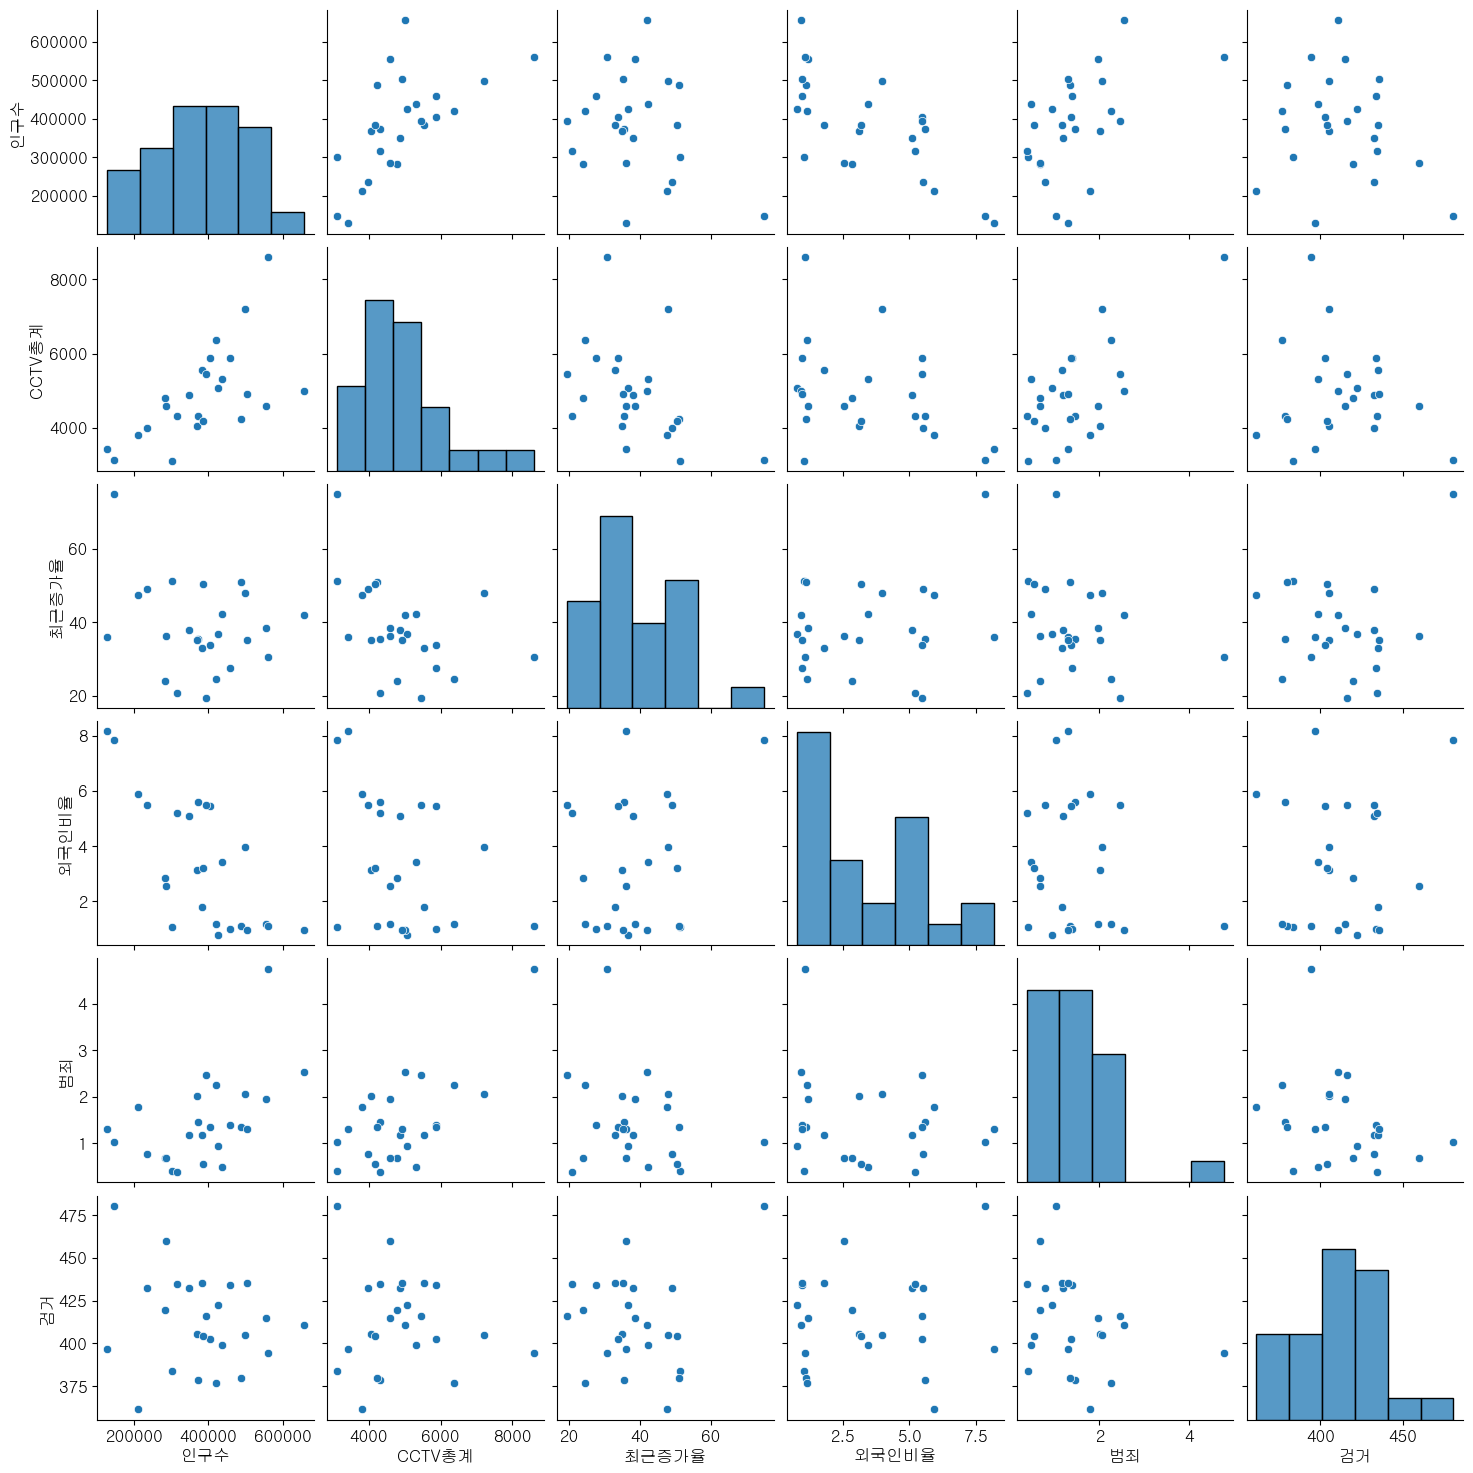

In [145]:
# CRIME_norm 으로 데이터를 주면 모든 데이터를 처리하느라 시간이 오래 걸림.
sns.pairplot(CRIME_norm[['인구수', 'CCTV총계', '최근증가율', '외국인비율', '범죄', '검거']])
plt.show()

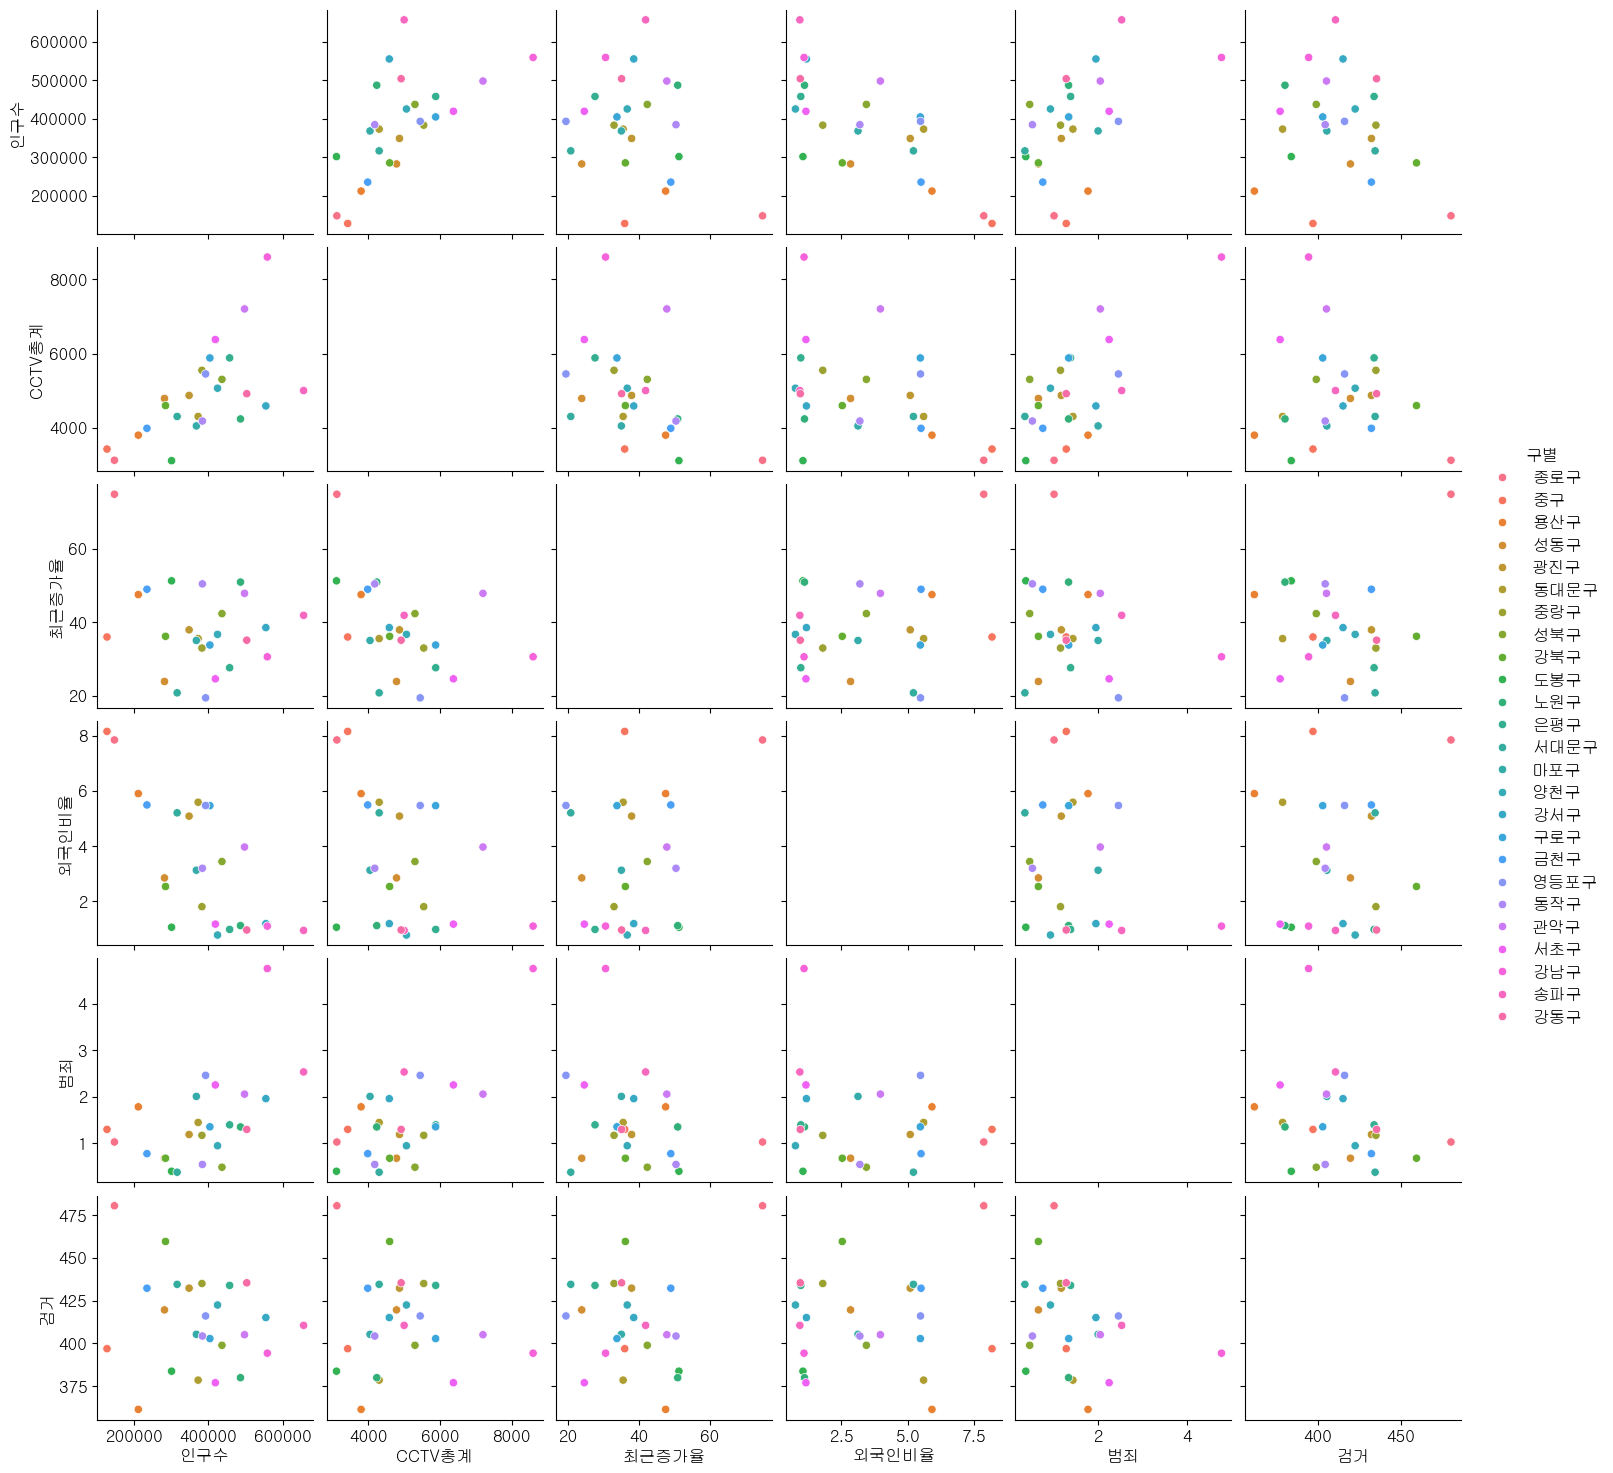

In [146]:
sns.pairplot(CRIME_norm[['인구수', 'CCTV총계', '최근증가율', '외국인비율', '범죄', '검거']].reset_index()
             , hue='구별'
            )
plt.show()

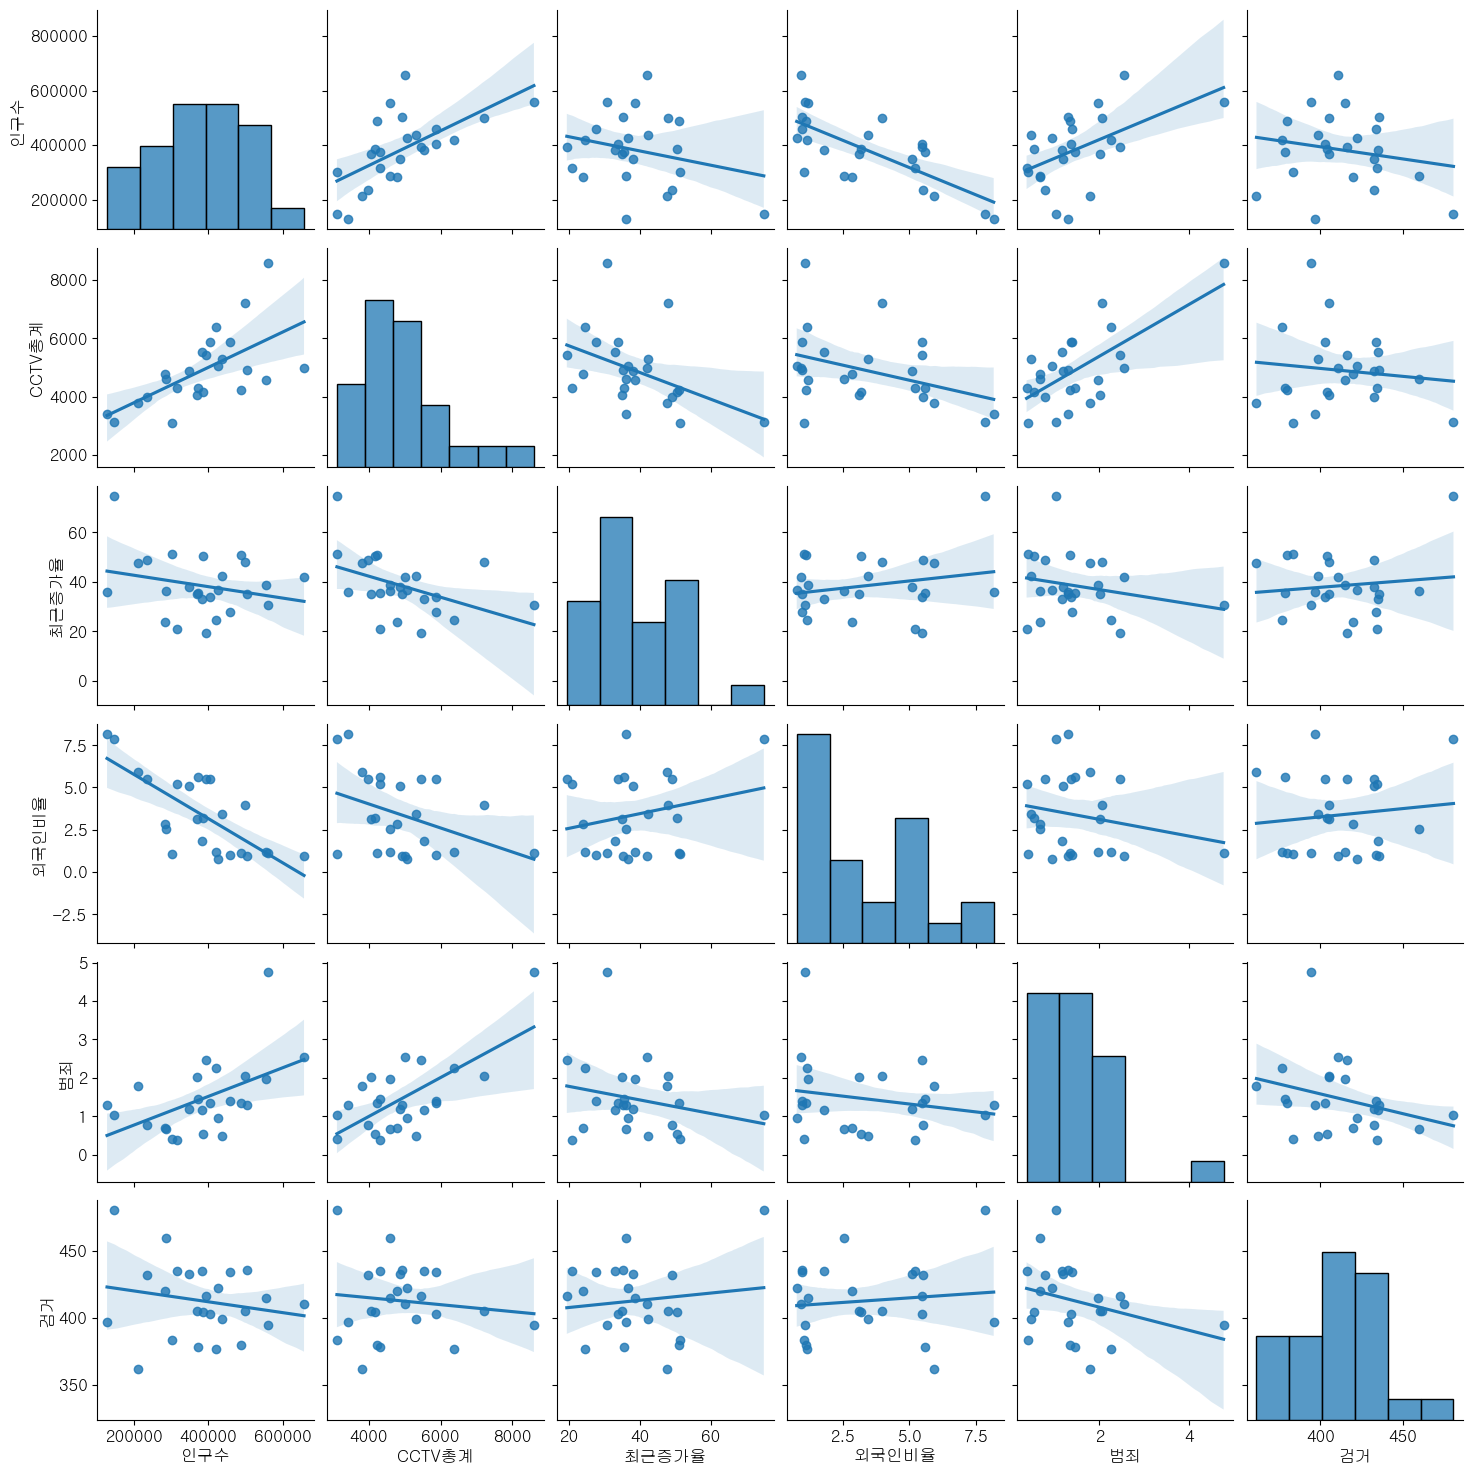

In [147]:
sns.pairplot(CRIME_norm[['인구수', 'CCTV총계', '최근증가율', '외국인비율', '범죄', '검거']]
            , kind='reg')
plt.show()

In [148]:
CRIME_norm.head(1)

,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율,범죄,검거,인구수,CCTV총계,외국인비율,최근증가율
구별,,,,,,,,,,,,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958,100.0,100.0,100.0,89.264582,91.215227,1.029631,480.479809,148154,3125,7.85399,74.848


In [149]:
CRIME_norm['검거'].max()

480.4798085122446

In [152]:
CRIME_norm['검거'] = CRIME_norm['검거'] / CRIME_norm['검거'].max() * 100

In [155]:
CRIME_norm.head(2)

,살인,강도,강간강제추행,절도,폭력,살인검거율,강도검거율,강간강제추행검거율,절도검거율,폭력검거율,범죄,검거,인구수,CCTV총계,외국인비율,최근증가율
구별,,,,,,,,,,,,,,,,
종로구,0.066667,0.294118,0.239859,0.225029,0.203958,100.0,100.0,100.000000,89.264582,91.215227,1.029631,100.00000,148154,3125,7.853990,74.84800
중구,0.266667,0.294118,0.183422,0.351351,0.205574,80.0,100.0,68.361582,58.369099,90.072993,1.301131,82.58488,128234,3427,8.163981,36.00817


## 히트맵(heatmap) : 2차원 배열 데이터 -> 색상으로 시각화 

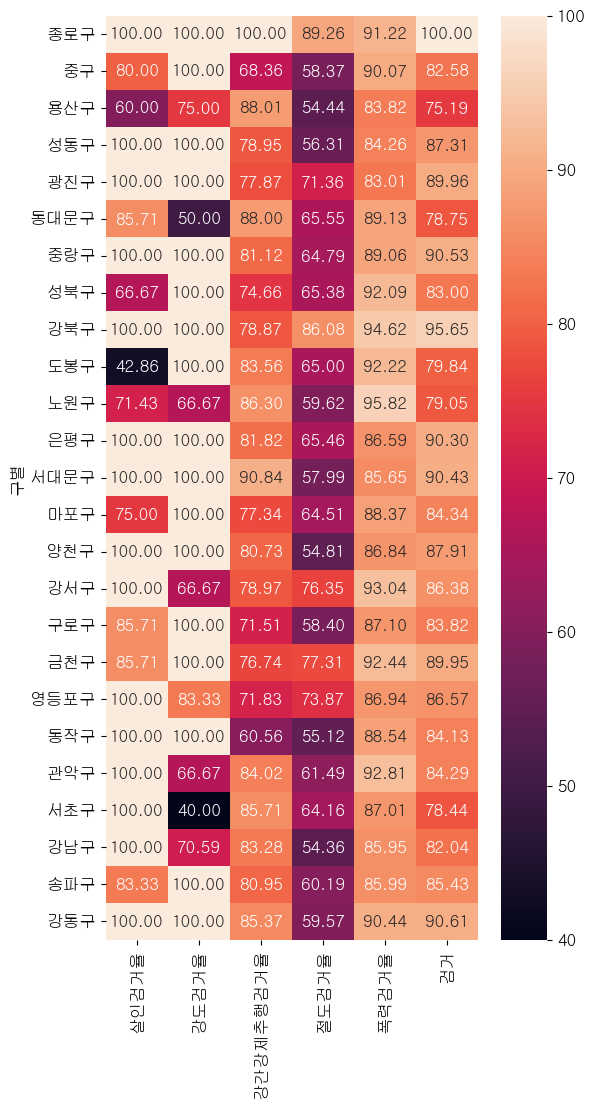

In [158]:
plt.figure(figsize=(6,12), dpi=100)
sns.heatmap(CRIME_norm[['살인검거율', '강도검거율', '강간강제추행검거율', '절도검거율', '폭력검거율', '검거']]
           , annot=True, fmt='.2f')
plt.show()

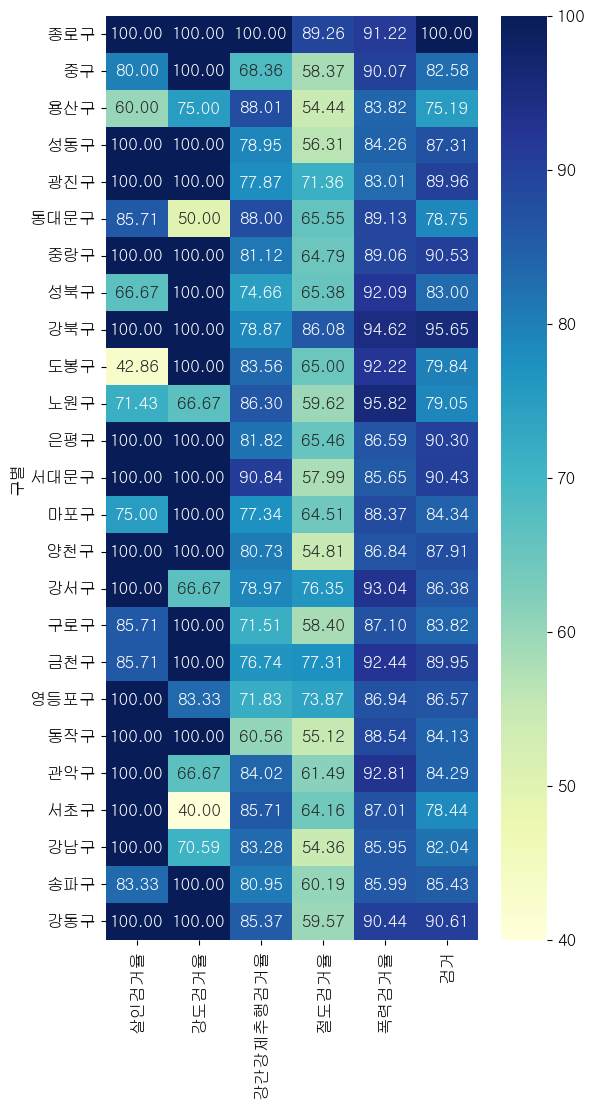

In [159]:
plt.figure(figsize=(6,12), dpi=100)
sns.heatmap(CRIME_norm[['살인검거율', '강도검거율', '강간강제추행검거율', '절도검거율', '폭력검거율', '검거']]
           , annot=True, fmt='.2f', cmap='YlGnBu')
plt.show()

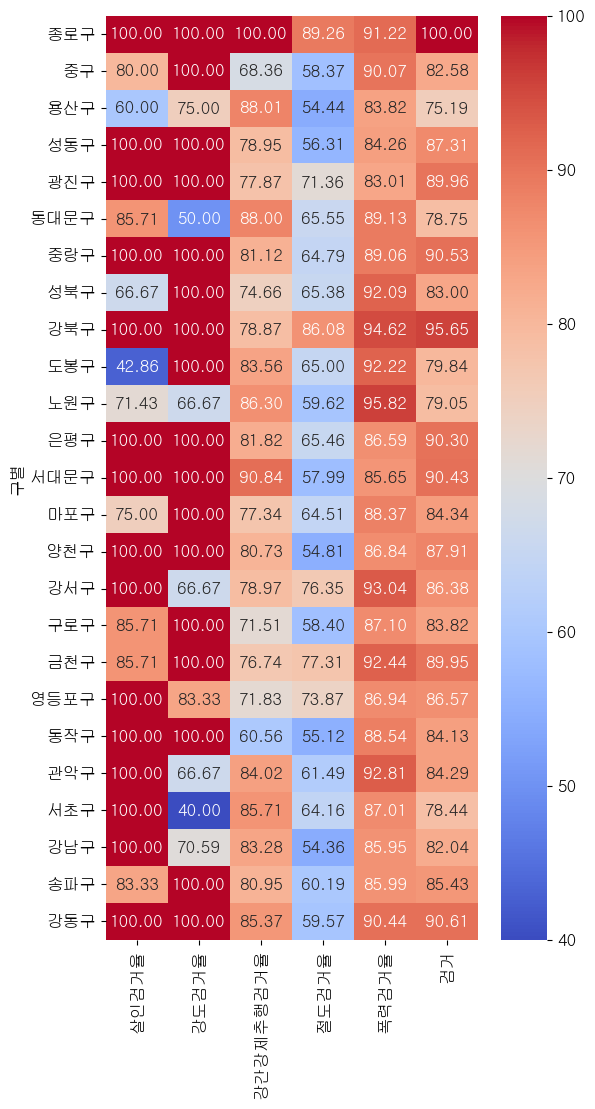

In [163]:
plt.figure(figsize=(6,12), dpi=100)
sns.heatmap(CRIME_norm[['살인검거율', '강도검거율', '강간강제추행검거율', '절도검거율', '폭력검거율', '검거']]
           , annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

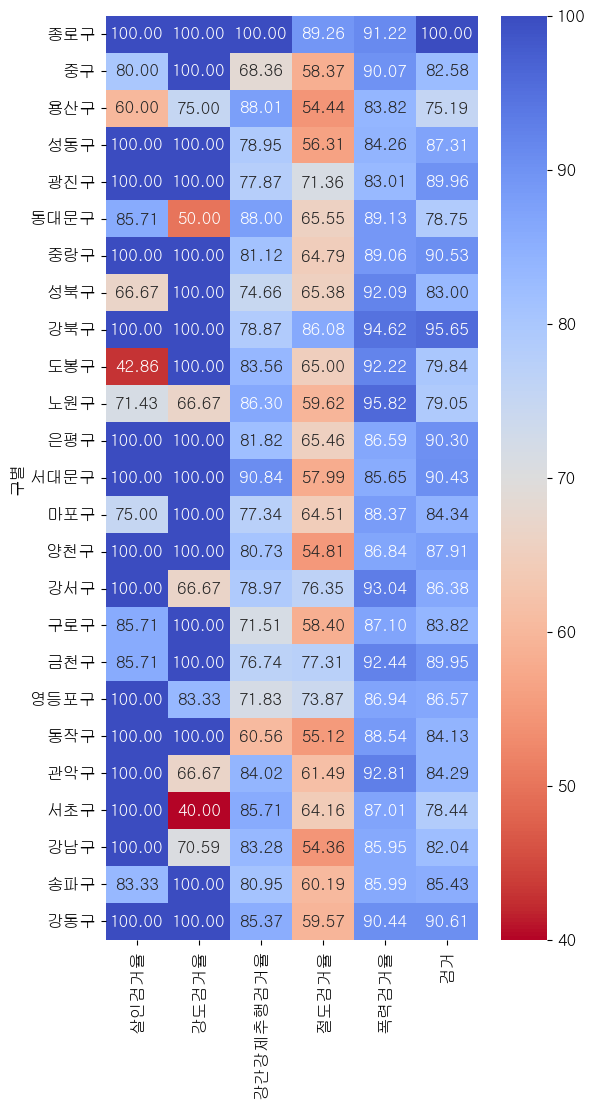

In [165]:
plt.figure(figsize=(6,12), dpi=100)
sns.heatmap(CRIME_norm[['살인검거율', '강도검거율', '강간강제추행검거율', '절도검거율', '폭력검거율', '검거']]
           , annot=True, fmt='.2f', cmap='coolwarm_r')
plt.show()

## 지도에 시각화

In [167]:
pip install folium

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.


In [168]:
import folium

In [ ]:
yu_map = folium.Map(location=[35.8327, 128.7546], zoom_start=15)
yu_map

In [182]:
folium.Marker([35.8327, 128.7546], popup='YU').add_to(yu_map)

In [183]:
yu_map

In [ ]:
folium.CircleMarker([35.84, 128.7546], radius=50, popup='컴공', fill_color='#ff0000').add_to(yu_map)
yu_map

# 한국 지도 정보

In [189]:
import json

In [191]:
seoul_geo = json.load(open('seoul_geo.json', encoding='utf-8'))

In [192]:
seoul_geo

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'properties': {'code': '11250',
    'name': '강동구',
    'name_eng': 'Gangdong-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.11519584981606, 37.557533180704915],
      [127.16683184366129, 37.57672487388627],
      [127.18408792330152, 37.55814280369575],
      [127.16530984307447, 37.54221851258693],
      [127.14672806823502, 37.51415680680291],
      [127.12123165719615, 37.52528270089],
      [127.1116764203608, 37.540669955324965],
      [127.11519584981606, 37.557533180704915]]]}},
  {'type': 'Feature',
   'properties': {'code': '11240',
    'name': '송파구',
    'name_eng': 'Songpa-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.0690698130372, 37.522279423505026],
      [127.10087519791962, 37.524841220167055],
      [127.1116764203608, 37.540669955324965],
      [127.12123165719615, 37.52528270089],
      [127.14672806823502, 37

In [201]:
seoul_map = folium.Map(location=[37.5502, 126.982], zoomstart=12)

# 코로플레스 맵 : 지리적 구역을 나눠놓은 지도
folium.Choropleth(geo_data=seoul_geo,
                data = CRIME_norm['범죄'],
                 columns = [CRIME_norm.index, CRIME_norm['범죄']],
                 fill_color = 'PuRd',
                 key_on = 'feature.properties.name').add_to(seoul_map)

In [204]:
seoul_map